In [1]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, balanced_accuracy_score,
                              accuracy_score)
from pathlib import Path
WAV_DIR = Path("C:/Users/asalou/S7/stages7/project/wav_audio")
LAB_DIR = Path("C:/Users/asalou/S7/stages7/project/labels")
OUTPUT_DIR = Path("C:/Users/asalou/S7/stages7/project/augmentation/aug")
TARGET_SR  = 16000
SEG_LEN    = 8000

dataset = {}

for file in WAV_DIR.glob("*.wav"):
    y, sr = librosa.load(file, sr=16000)

    dataset[file.stem] = {
        'data': y,
        'filtered': y.copy(),   
        'sr': sr,
        'duration': len(y)/sr,
        'energy': None,
        'times': None,
        'threshold': None,
        'segments': []
    }
print("Dataset chargé :", len(dataset))
# ── Paramètres spectrogramme ──────────────────────────────────
N_MELS   = 64    # nb de bandes Mel  → hauteur de l'image
N_FFT    = 512   # fenêtre FFT
HOP_LEN  = 160   # pas = 10ms → largeur de l'image ≈ 50 frames
# Résultat : image (64, 50) par segment

Dataset chargé : 21


In [2]:
# ── Charger labels_check depuis le JSON ───────────────────────
import json
with open(f'{OUTPUT_DIR}/labels_segments.json') as f:
    labels_check = json.load(f)

print(f"labels_check chargé : {len(labels_check)} fichiers")
print(f"   Exemple : {list(labels_check.keys())[0]}")

labels_check chargé : 21 fichiers
   Exemple : Audio_1


In [3]:
# ════════════════════════════════════════════════════════════════
# SEGMENTATION AVEC CHEVAUCHEMENT 50%
# ════════════════════════════════════════════════════════════════

SEGMENT_MS  = 500
HOP_MS      = 250
SEG_LEN     = int(SEGMENT_MS * TARGET_SR / 1000)   # 8000 samples
HOP_LEN_AUD = int(HOP_MS     * TARGET_SR / 1000)   # 4000 samples

print(f"Segmentation avec chevauchement 50%")
print(f"  Segment : {SEGMENT_MS}ms ({SEG_LEN} samples)")
print(f"  Hop     : {HOP_MS}ms    ({HOP_LEN_AUD} samples)")
print("="*55)

segments_overlap = {
    'miction_active': [],
    'bruit_ambiant':  [],
    'bruit_chasse':   [],
    'silence':        [],
}

for nom_fichier, labels_orig in labels_check.items():
    if nom_fichier not in dataset:
        continue

    filt        = dataset[nom_fichier]['filtered']
    sr          = dataset[nom_fichier]['sr']
    n_segs_orig = len(labels_orig)
    pos         = 0
    n_segs      = 0

    while pos + SEG_LEN <= len(filt):
        segment = filt[pos:pos + SEG_LEN]

        # Label hérité du segment original contenant le centre
        centre_s    = (pos + SEG_LEN // 2) / sr
        orig_id     = min(int(centre_s / 0.5), n_segs_orig - 1)
        lbl         = labels_orig[orig_id]

        if lbl in segments_overlap:
            segments_overlap[lbl].append(segment.copy())

        pos    += HOP_LEN_AUD
        n_segs += 1

    print(f"  {nom_fichier:40s} : {n_segs:4d} segments")

print("\nDistribution par classe :")
for lbl, segs in segments_overlap.items():
    print(f"  {lbl:20s} : {len(segs):4d}")
print(f"\nTotal : {sum(len(s) for s in segments_overlap.values())} segments")

Segmentation avec chevauchement 50%
  Segment : 500ms (8000 samples)
  Hop     : 250ms    (4000 samples)
  Audio_1                                  :  168 segments
  Audio_10                                 :  127 segments
  Audio_11                                 :  138 segments
  Audio_12                                 :  158 segments
  Audio_13                                 :  138 segments
  Audio_14                                 :  192 segments
  Audio_15                                 :  147 segments
  Audio_16                                 :  169 segments
  Audio_17                                 :  104 segments
  Audio_18                                 :  149 segments
  Audio_19                                 :  122 segments
  Audio_2                                  :  192 segments
  Audio_20                                 :  193 segments
  Audio_3                                  :  122 segments
  Audio_4                                  :  218 segments
  Audio_5 

In [4]:
# ════════════════════════════════════════════════════════════════
# FONCTIONS D'AUGMENTATION
# ════════════════════════════════════════════════════════════════

def aug_bruit(seg, sr, sigma=0.005):
    """Ajout de bruit gaussien."""
    return seg + np.random.normal(0, sigma, len(seg))

def aug_gain(seg, sr, low=0.7, high=1.3):
    """Variation de gain aléatoire."""
    return seg * np.random.uniform(low, high)

def aug_shift(seg, sr, max_ms=50):
    """Décalage temporel aléatoire."""
    shift = int(np.random.uniform(-max_ms, max_ms) * sr / 1000)
    return np.roll(seg, shift)

def aug_stretch(seg, sr, low=0.9, high=1.1):
    """Time stretching puis recadrage à la longueur originale."""
    rate      = np.random.uniform(low, high)
    stretched = librosa.effects.time_stretch(seg.astype(float), rate=rate)
    # Recadrer à SEG_LEN
    if len(stretched) >= SEG_LEN:
        return stretched[:SEG_LEN]
    else:
        return np.pad(stretched, (0, SEG_LEN - len(stretched)))

def aug_pitch(seg, sr, steps=(-2, -1, 1, 2)):
    """Pitch shifting d'un nombre de demi-tons aléatoire."""
    n = np.random.choice(steps)
    return librosa.effects.pitch_shift(seg.astype(float), sr=sr, n_steps=n)

def augmenter_segment(seg, sr, methode=None):
    """
    Applique une augmentation aléatoire ou spécifique.
    Combine toujours bruit + une autre technique.
    """
    methodes = [aug_gain, aug_shift, aug_stretch, aug_pitch]
    if methode is None:
        methode = np.random.choice(methodes)
    seg_aug = methode(seg, sr)
    seg_aug = aug_bruit(seg_aug, sr, sigma=np.random.uniform(0.001, 0.008))
    # Renormaliser
    mx = np.max(np.abs(seg_aug))
    if mx > 0:
        seg_aug = seg_aug / mx * np.max(np.abs(seg))
    return seg_aug.astype(np.float32)

In [5]:
# ── Augmentation ──────────────────────────────────────────────
TARGET_OV = 1500
np.random.seed(42)

segs_liste, labs_liste = [], []
print(f"Augmentation → {TARGET_OV} par classe")
print("="*55)

for lbl, segs_orig in segments_overlap.items():
    n_orig   = len(segs_orig)
    n_needed = max(0, TARGET_OV - n_orig)
    tous     = list(segs_orig)
    for _ in range(n_needed):
        src = segs_orig[np.random.randint(len(segs_orig))]
        tous.append(augmenter_segment(src, TARGET_SR))
    segs_liste.extend(tous)
    labs_liste.extend([lbl] * len(tous))
    print(f"  {lbl:20s} : {n_orig} originaux + {n_needed} augmentés = {len(tous)}")

    
# ── Sauvegarder ───────────────────────────────────────────────
X_ov = np.array(segs_liste, dtype=np.float32)
y_ov = np.array(labs_liste)
np.save(f'{OUTPUT_DIR}/X_augmented.npy', X_ov)
np.save(f'{OUTPUT_DIR}/y_augmented.npy', y_ov)

print(f"\n Dataset final : {X_ov.shape}  — ratio 1:1")
print(pd.Series(y_ov).value_counts().to_string())

Augmentation → 1500 par classe
  miction_active       : 1365 originaux + 135 augmentés = 1500
  bruit_ambiant        : 909 originaux + 591 augmentés = 1500
  bruit_chasse         : 453 originaux + 1047 augmentés = 1500
  silence              : 310 originaux + 1190 augmentés = 1500

 Dataset final : (6000, 8000)  — ratio 1:1
miction_active    1500
bruit_ambiant     1500
bruit_chasse      1500
silence           1500


Forme spectrogramme : (64, 51)  (n_mels=64, T=51)


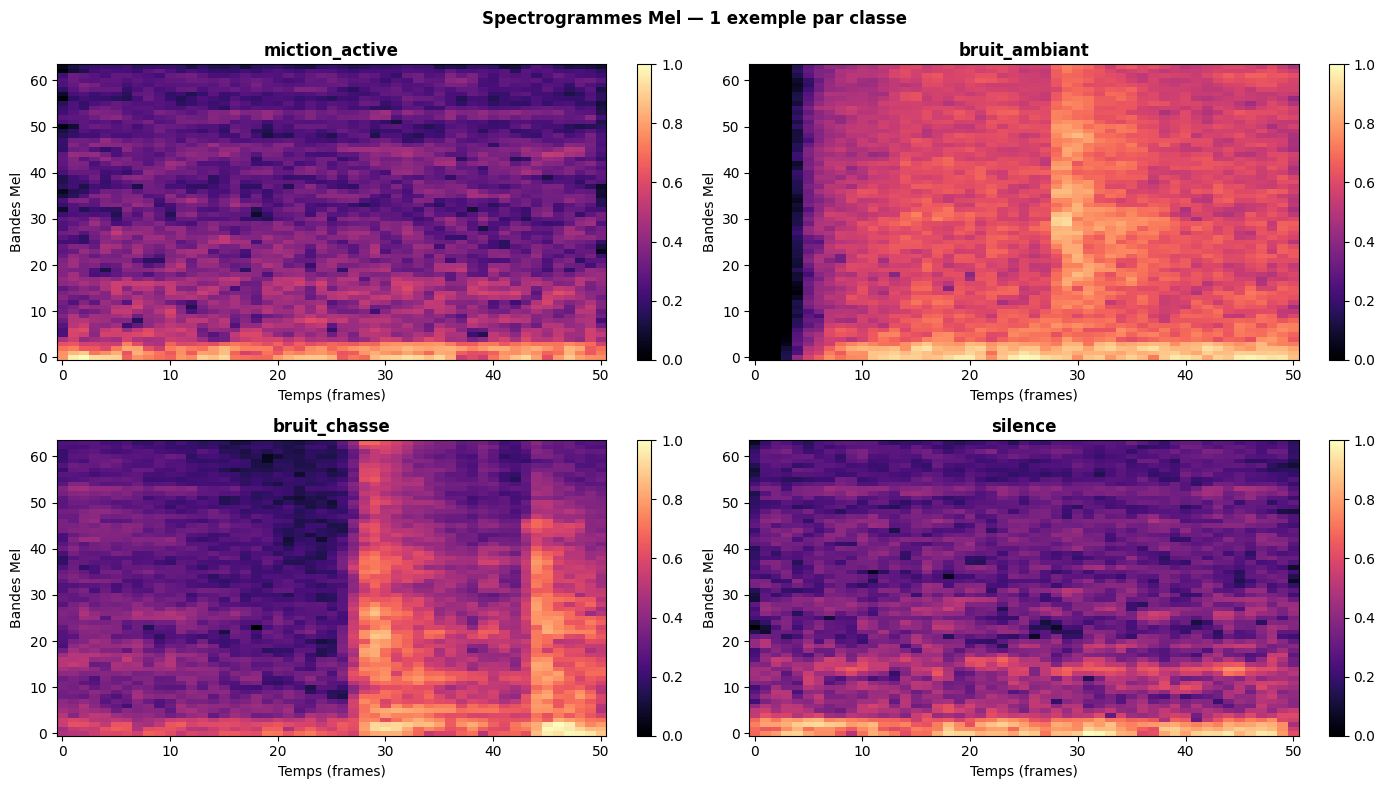

In [6]:
# ════════════════════════════════════════════════════════════════
# CONVERSION SIGNAL → SPECTROGRAMME MEL
# Chaque segment 8000 samples → image (64, 50)
# ════════════════════════════════════════════════════════════════

def signal_to_melspec(segment, sr=TARGET_SR,
                       n_mels=N_MELS, n_fft=N_FFT, hop_len=HOP_LEN):
    """
    Convertit un segment audio en spectrogramme Mel log-normalisé.
    
    Entrée  : signal float32 (8000 samples)
    Sortie  : image (n_mels, T) normalisée [0, 1]
    """
    mel = librosa.feature.melspectrogram(
        y=segment.astype(float), sr=sr,
        n_mels=n_mels, n_fft=n_fft,
        hop_length=hop_len, fmax=6000
    )
    # Conversion en dB
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Normalisation [0, 1]
    mel_min = mel_db.min()
    mel_max = mel_db.max()
    if mel_max - mel_min > 0:
        mel_norm = (mel_db - mel_min) / (mel_max - mel_min)
    else:
        mel_norm = np.zeros_like(mel_db)

    return mel_norm.astype(np.float32)

# ── Test sur un segment ───────────────────────────────────────
X_raw = np.load(f'{OUTPUT_DIR}/X_augmented.npy')
y_raw = np.load(f'{OUTPUT_DIR}/y_augmented.npy')

spec_test = signal_to_melspec(X_raw[0])
print(f"Forme spectrogramme : {spec_test.shape}  "
      f"(n_mels={spec_test.shape[0]}, T={spec_test.shape[1]})")

# ── Visualisation des 4 classes ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Spectrogrammes Mel — 1 exemple par classe', fontweight='bold')

for ax, lbl in zip(axes.flat, ['miction_active','bruit_ambiant',
                                 'bruit_chasse','silence']):
    idx  = np.where(y_raw == lbl)[0][0]
    spec = signal_to_melspec(X_raw[idx])
    im   = ax.imshow(spec, origin='lower', aspect='auto',
                     cmap='magma', vmin=0, vmax=1)
    ax.set_title(lbl, fontweight='bold')
    ax.set_xlabel('Temps (frames)'); ax.set_ylabel('Bandes Mel')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/mel_spectrograms.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# ════════════════════════════════════════════════════════════════
# CONVERSION DATASET COMPLET → SPECTROGRAMMES
# ════════════════════════════════════════════════════════════════

print("Conversion dataset → spectrogrammes Mel...")
print("(6000 segments × (64, 50) = patience ~1min)")

X_mel = np.array([signal_to_melspec(seg) for seg in X_raw],
                  dtype=np.float32)

# Ajouter dimension canal : (N, 64, 50) → (N, 64, 50, 1)
X_mel = X_mel[..., np.newaxis]

print(f" X_mel shape : {X_mel.shape}")
print(f"   Min={X_mel.min():.3f}  Max={X_mel.max():.3f}  "
      f"Moy={X_mel.mean():.3f}")

# ── Encodage labels + split ───────────────────────────────────
le    = LabelEncoder()
y_enc = le.fit_transform(y_raw)
print(f"\nClasses : {le.classes_}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X_mel, y_enc, test_size=0.30, stratify=y_enc, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f"\nSplit 70/15/15 :")
print(f"  Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

# Sauvegarder pour réutilisation
np.save(f'{OUTPUT_DIR}/X_mel.npy', X_mel)
np.save(f'{OUTPUT_DIR}/y_enc.npy', y_enc)
print(f"X_mel.npy sauvegardé")

Conversion dataset → spectrogrammes Mel...
(6000 segments × (64, 50) = patience ~1min)
 X_mel shape : (6000, 64, 51, 1)
   Min=0.000  Max=1.000  Moy=0.424

Classes : ['bruit_ambiant' 'bruit_chasse' 'miction_active' 'silence']

Split 70/15/15 :
  Train : 4200 | Val : 900 | Test : 900
X_mel.npy sauvegardé


In [10]:
# ════════════════════════════════════════════════════════════════
# ARCHITECTURE CNN + LSTM
# CNN  → extrait features locales temps-fréquence
# LSTM → modélise la dynamique temporelle entre frames
#
# Entrée : spectrogramme Mel (64, 50, 1)
#   → CNN extrait (T, features) pour chaque frame temporelle
#   → LSTM lit la séquence de T frames
#   → Dense → Softmax
# ════════════════════════════════════════════════════════════════
from tensorflow.keras import backend as K
K.clear_session()

def build_cnn_lstm(input_shape=(64, 50, 1), n_classes=4):
    inputs = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,1))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,1))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,1))(x)
    x = layers.Dropout(0.30)(x)

    # ── Reshape pour LSTM ──────────────────────────────────────
    # Permute : (batch, freq, temps, filtres) → (batch, temps, freq, filtres)
    x = layers.Permute((2, 1, 3))(x)

    # -1 laisse Keras calculer automatiquement freq×filtres
    t_dim = x.shape[1]   # dimension temps réelle après convolutions
    x = layers.Reshape((t_dim, -1))(x)   # (batch, T, freq×filtres)

    # ── LSTM ──────────────────────────────────────────────────
    x = layers.LSTM(128, return_sequences=True,
                     dropout=0.30, recurrent_dropout=0.20)(x)
    x = layers.LSTM(64,  return_sequences=False,
                     dropout=0.30, recurrent_dropout=0.20)(x)

    # ── Classifieur ───────────────────────────────────────────
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(64,  activation='relu')(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='CNN_LSTM_Miction')

K.clear_session()
model_lstm = build_cnn_lstm(input_shape=X_train.shape[1:], n_classes=4)
model_lstm.summary()
print(f"\nParamètres : {model_lstm.count_params():,}")

Model: "CNN_LSTM_Miction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 51, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 51, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64, 51, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 51, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 51, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 51, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 51, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 51, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 51, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 51, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32, 51, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 51, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 51, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 51, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 16, 51, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 51, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8, 51, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ permute (Permute)                    │ (None, 51, 8, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 51, 1024)            │              

 Total params: 796,708 (3.04 MB)

 Trainable params: 796,068 (3.04 MB)

 Non-trainable params: 640 (2.50 KB)


Paramètres : 796,708


In [11]:
# ── Entraînement ──────────────────────────────────────────────
model_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Entraînement CNN + LSTM...")
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=15,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=7, min_lr=1e-6, verbose=1),
        keras.callbacks.ModelCheckpoint(
            f'{OUTPUT_DIR}/cnn_lstm_best.keras',
            monitor='val_accuracy', save_best_only=True, verbose=0),
    ],
    verbose=1
)

Entraînement CNN + LSTM...
Epoch 1/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 91s 621ms/step - accuracy: 0.4990 - loss: 1.1536 - val_accuracy: 0.2500 - val_loss: 1.3869 - learning_rate: 5.0000e-04
Epoch 2/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 89s 671ms/step - accuracy: 0.6881 - loss: 0.7951 - val_accuracy: 0.3300 - val_loss: 1.3852 - learning_rate: 5.0000e-04
Epoch 3/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 85s 647ms/step - accuracy: 0.7429 - loss: 0.6686 - val_accuracy: 0.3378 - val_loss: 1.6893 - learning_rate: 5.0000e-04
Epoch 4/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 87s 660ms/step - accuracy: 0.7629 - loss: 0.6105 - val_accuracy: 0.6389 - val_loss: 0.8630 - learning_rate: 5.0000e-04
Epoch 5/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 89s 673ms/step - accuracy: 0.7774 - loss: 0.5845 - val_accuracy: 0.7689 - val_loss: 0.5978 - learning_rate: 5.0000e-04
Epoch 6/50
132/132 ━━━━━━━━━━━━━━━━━━━━ 85s 641ms/step - accuracy: 0.7848 - loss: 0.5719 - val_accuracy: 0.8156 - val_loss: 0.4997 - learning_rate: 5.0000e-04
Epoch 7/50
132/132 

RÉSULTATS CNN + LSTM
Accuracy          : 0.849
Balanced Accuracy : 0.849

                precision    recall  f1-score   support

 bruit_ambiant      0.705     0.764     0.733       225
  bruit_chasse      0.981     0.898     0.937       225
miction_active      0.971     0.893     0.931       225
       silence      0.778     0.840     0.808       225

      accuracy                          0.849       900
     macro avg      0.859     0.849     0.852       900
  weighted avg      0.859     0.849     0.852       900



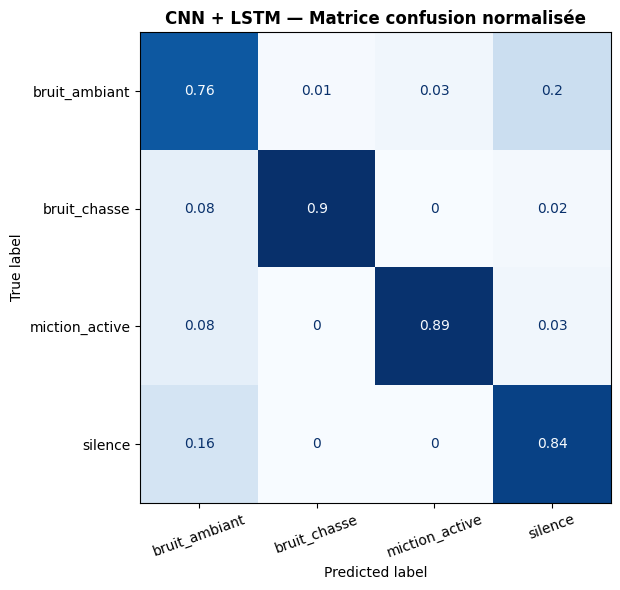


BILAN COMPLET
Modèle                              |  Accuracy |   Bal.Acc
------------------------------------------------------------
SVM RBF                             |     0.766 |     0.777
CNN 2D sans chevauch.               |     0.851 |     0.851
CNN 2D chevauch. 50%                |     0.877 |     0.877
CNN + LSTM chevauch. 50%            |     0.849 |     0.849


In [20]:
# ── Évaluation + comparaison ──────────────────────────────────
y_pred_lstm = np.argmax(model_lstm.predict(X_test, verbose=0), axis=1)
acc_lstm    = accuracy_score(y_test, y_pred_lstm)
bal_lstm    = balanced_accuracy_score(y_test, y_pred_lstm)

print("="*60)
print("RÉSULTATS CNN + LSTM")
print("="*60)
print(f"Accuracy          : {acc_lstm:.3f}")
print(f"Balanced Accuracy : {bal_lstm:.3f}")
print(f"\n{classification_report(y_test, y_pred_lstm, target_names=le.classes_, digits=3)}")

# ── Matrice de confusion ──────────────────────────────────────
cm      = confusion_matrix(y_test, y_pred_lstm)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=le.classes_).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('CNN + LSTM — Matrice confusion normalisée', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cnn_lstm_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Bilan complet ─────────────────────────────────────────────
print("\n" + "="*60)
print("BILAN COMPLET")
print("="*60)
print(f"{'Modèle':35s} | {'Accuracy':>9} | {'Bal.Acc':>9}")
print("-"*60)
print(f"{'SVM RBF':35s} | {'0.766':>9} | {'0.777':>9}")
print(f"{'CNN 2D sans chevauch.':35s} | {'0.851':>9} | {'0.851':>9}")
print(f"{'CNN 2D chevauch. 50%':35s} | {'0.877':>9} | {'0.877':>9}")
print(f"{'CNN + LSTM chevauch. 50%':35s} | {acc_lstm:9.3f} | {bal_lstm:9.3f}")
print("="*60)



In [23]:
# ════════════════════════════════════════════════════════════════
# PHASE DE CORRECTION — CNN + LSTM chevauchement 50%
# ════════════════════════════════════════════════════════════════

def corriger_contexte(labels, fenetre=1):
    labels = list(labels)
    corrections = []
    for i in range(fenetre, len(labels) - fenetre):
        vg = labels[i - fenetre]
        vd = labels[i + fenetre]
        if vg == vd and labels[i] != vg:
            corrections.append({'segment':i, 'avant':labels[i], 'apres':vg})
            labels[i] = vg
    return labels, corrections
tous_avant, tous_apres, tous_vrais = [], [], []
total_corrections = []

print("Phase de correction — CNN + LSTM chevauchement 50%")
print("="*65)

for nom_fichier, labels_orig in labels_check.items():
    if nom_fichier not in dataset:
        continue

    filt        = dataset[nom_fichier]['filtered']
    sr          = dataset[nom_fichier]['sr']
    n_segs_orig = len(labels_orig)

    # ── Reconstruire segments avec chevauchement ──────────────
    segments, labels_vrais, pos = [], [], 0
    while pos + SEG_LEN <= len(filt):
        segment     = filt[pos:pos + SEG_LEN]
        centre_s    = (pos + SEG_LEN // 2) / sr
        orig_id     = min(int(centre_s / 0.5), n_segs_orig - 1)
        segments.append(segment)
        labels_vrais.append(labels_orig[orig_id])
        pos += HOP_LEN_AUD

    # ── Prédire avec CNN + LSTM ───────────────────────────────
    X_mel_f    = np.array([signal_to_melspec(s) for s in segments])[..., np.newaxis]
    probas     = model_lstm.predict(X_mel_f, verbose=0)
    labels_pred = list(le.inverse_transform(np.argmax(probas, axis=1)))

    # ── Corriger ──────────────────────────────────────────────
    labels_corr, corrections = corriger_contexte(labels_pred, fenetre=1)

    tous_avant.extend(labels_pred)
    tous_apres.extend(labels_corr)
    tous_vrais.extend(labels_vrais)
    total_corrections.extend(corrections)

    if corrections:
        print(f"  {nom_fichier:40s} : {len(corrections)} corrections")

print("="*65)
print(f"Total corrections : {len(total_corrections)}")

# ── Métriques ─────────────────────────────────────────────────
acc_av  = accuracy_score(tous_vrais, tous_avant)
bal_av  = balanced_accuracy_score(tous_vrais, tous_avant)
acc_ap  = accuracy_score(tous_vrais, tous_apres)
bal_ap  = balanced_accuracy_score(tous_vrais, tous_apres)

print(f"\n{'':35s} | {'Accuracy':>9} | {'Bal.Acc':>9}")
print("-"*58)
print(f"{'CNN+LSTM avant correction':35s} | {acc_av:9.3f} | {bal_av:9.3f}")
print(f"{'CNN+LSTM après correction':35s} | {acc_ap:9.3f} | {bal_ap:9.3f}")
print(f"{'Gain':35s} | {acc_ap-acc_av:+9.3f} | {bal_ap-bal_av:+9.3f}")

# ── Types de corrections ──────────────────────────────────────
from collections import Counter
transitions = Counter([f"{c['avant']} → {c['apres']}"
                        for c in total_corrections])
print(f"\nTypes de corrections :")
for trans, count in transitions.most_common():
    print(f"  {trans:45s} : {count:3d}")

# ── Bilan complet final ───────────────────────────────────────
print("\n" + "="*65)
print("BILAN COMPLET FINAL")
print("="*65)
print(f"{'Modèle':40s} | {'Accuracy':>9} | {'Bal.Acc':>9}")
print("-"*65)
print(f"{'SVM RBF':40s} | {'0.766':>9} | {'0.777':>9}")
print(f"{'CNN 2D sans chevauch.':40s} | {'0.851':>9} | {'0.851':>9}")
print(f"{'CNN 2D chevauch. 50%':40s} | {'0.877':>9} | {'0.877':>9}")
print(f"{'CNN 2D chev. + correction':40s} | {'0.903':>9} | {'0.764':>9}")
print(f"{'CNN + LSTM chevauch. 50%':40s} | {'0.849':>9} | {'0.849':>9}")
print(f"{'CNN + LSTM + correction':40s} | {acc_ap:9.3f} | {bal_ap:9.3f}")
print("="*65)

Phase de correction — CNN + LSTM chevauchement 50%
  Audio_1                                  : 5 corrections
  Audio_10                                 : 4 corrections
  Audio_11                                 : 3 corrections
  Audio_12                                 : 1 corrections
  Audio_13                                 : 3 corrections
  Audio_14                                 : 6 corrections
  Audio_15                                 : 7 corrections
  Audio_16                                 : 2 corrections
  Audio_17                                 : 2 corrections
  Audio_18                                 : 2 corrections
  Audio_19                                 : 3 corrections
  Audio_2                                  : 6 corrections
  Audio_20                                 : 7 corrections
  Audio_3                                  : 3 corrections
  Audio_4                                  : 2 corrections
  Audio_5                                  : 1 corrections
  Aud